In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [55]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
X.shape

(500, 2)

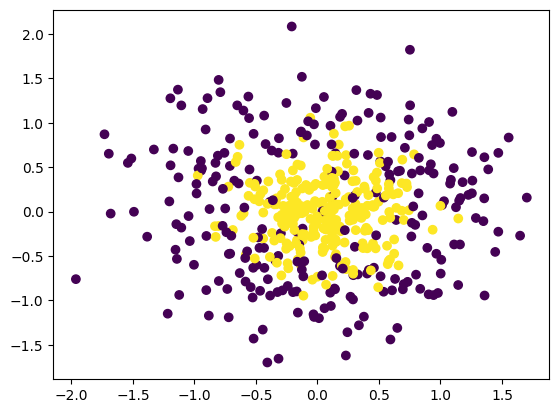

In [57]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

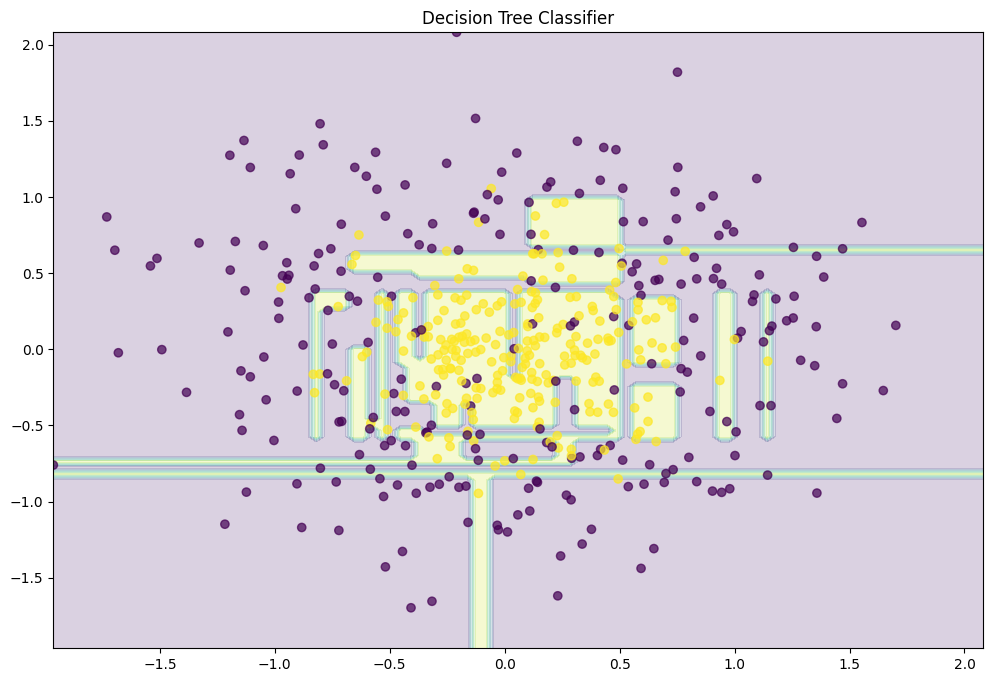

In [58]:
from sklearn.tree import DecisionTreeClassifier
dtree_clf = DecisionTreeClassifier(random_state=42)
dtree_clf.fit(X_train, y_train)

plt.figure(figsize=(12,8))
x_range = np.linspace(X.min(), X.max(), num=100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree_clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title('Decision Tree Classifier')
plt.show()

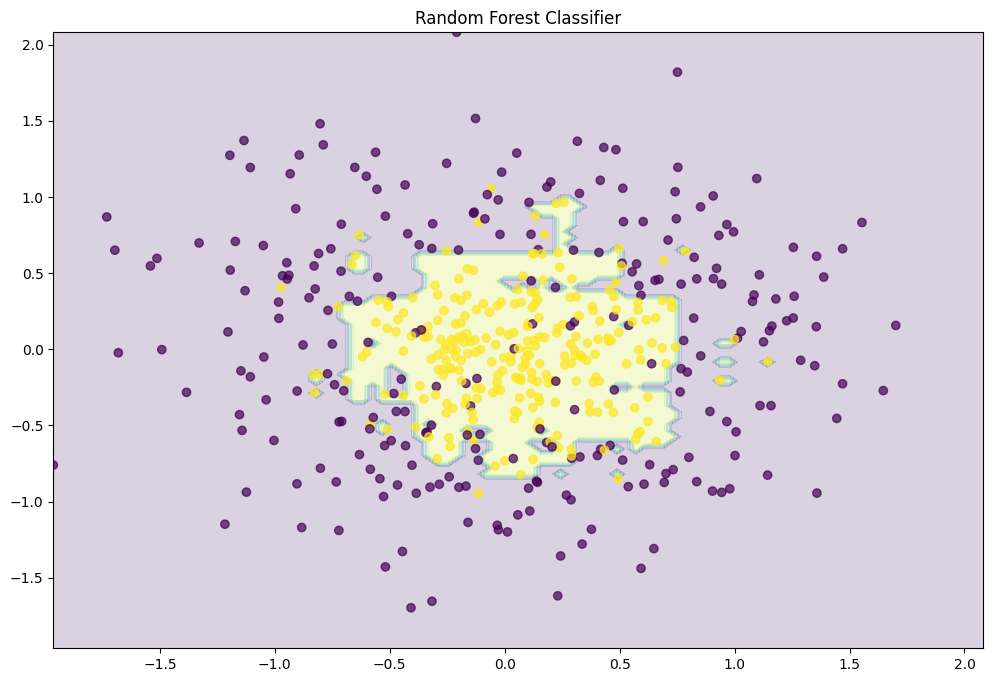

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rf_clf.fit(X_train, y_train)

plt.figure(figsize=(12,8))
x_range = np.linspace(X.min(), X.max(), num=100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf_clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
plt.title('Random Forest Classifier')
plt.show()

(-5.0, 5.0)

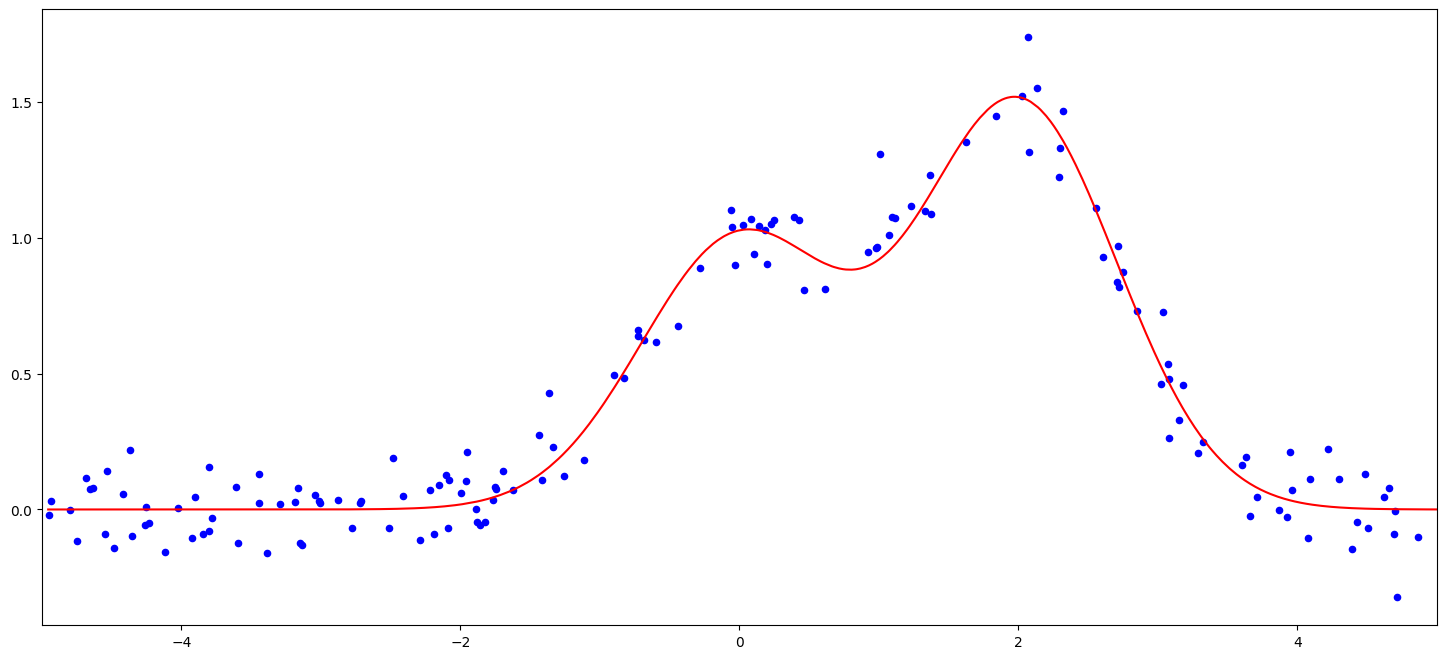

In [60]:
n_train, n_test, noise = 150, 1000, 0.1
# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x**2) + 1.5 * np.exp(-(x-2)**2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X**2) + 1.5 * np.exp(-(X-2)**2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))
    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.xlim([-5, 5])

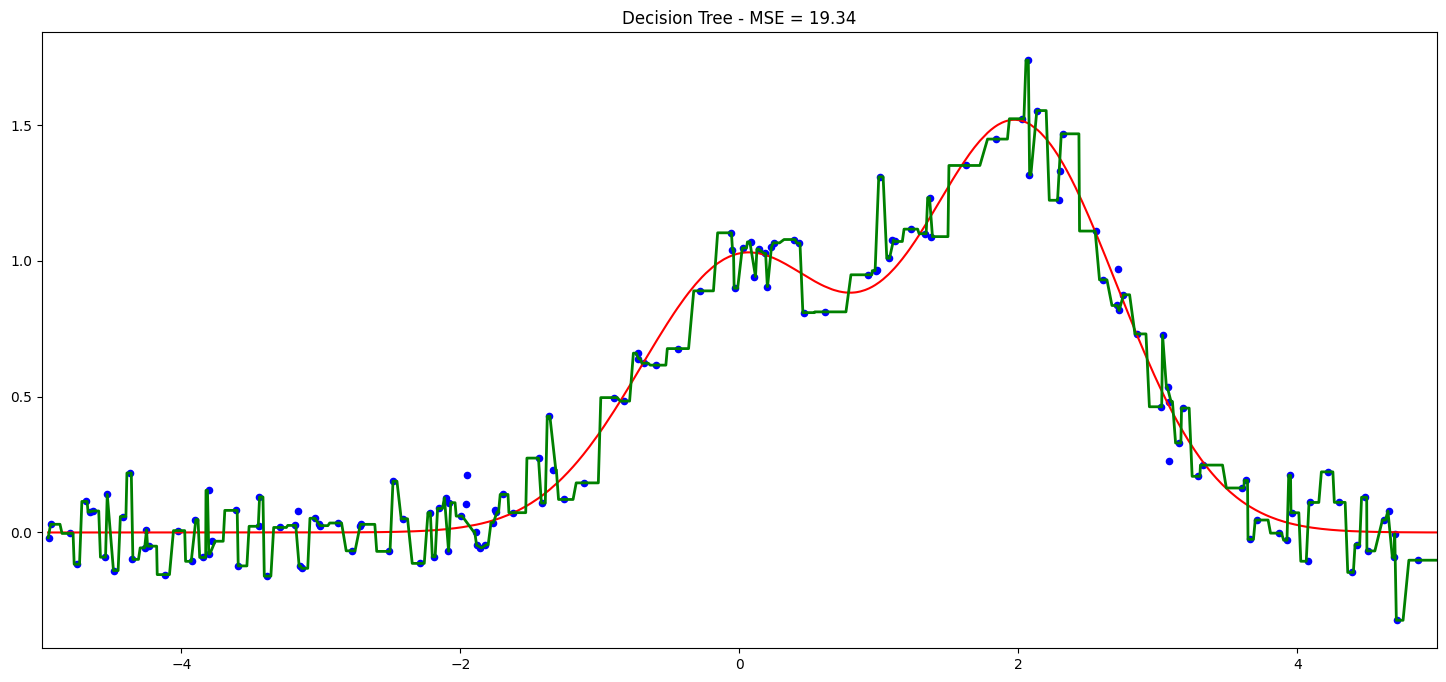

In [84]:
from sklearn.tree import DecisionTreeRegressor

dtree_reg = DecisionTreeRegressor()
dtree_reg.fit(X_train, y_train)
dt_pred = dtree_reg.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.plot(X_test, dt_pred, 'g', lw=2)
plt.xlim([-5,5])
plt.title("Decision Tree - MSE = %.2f"
         %np.sum((y_test - dt_pred)**2))
plt.show()

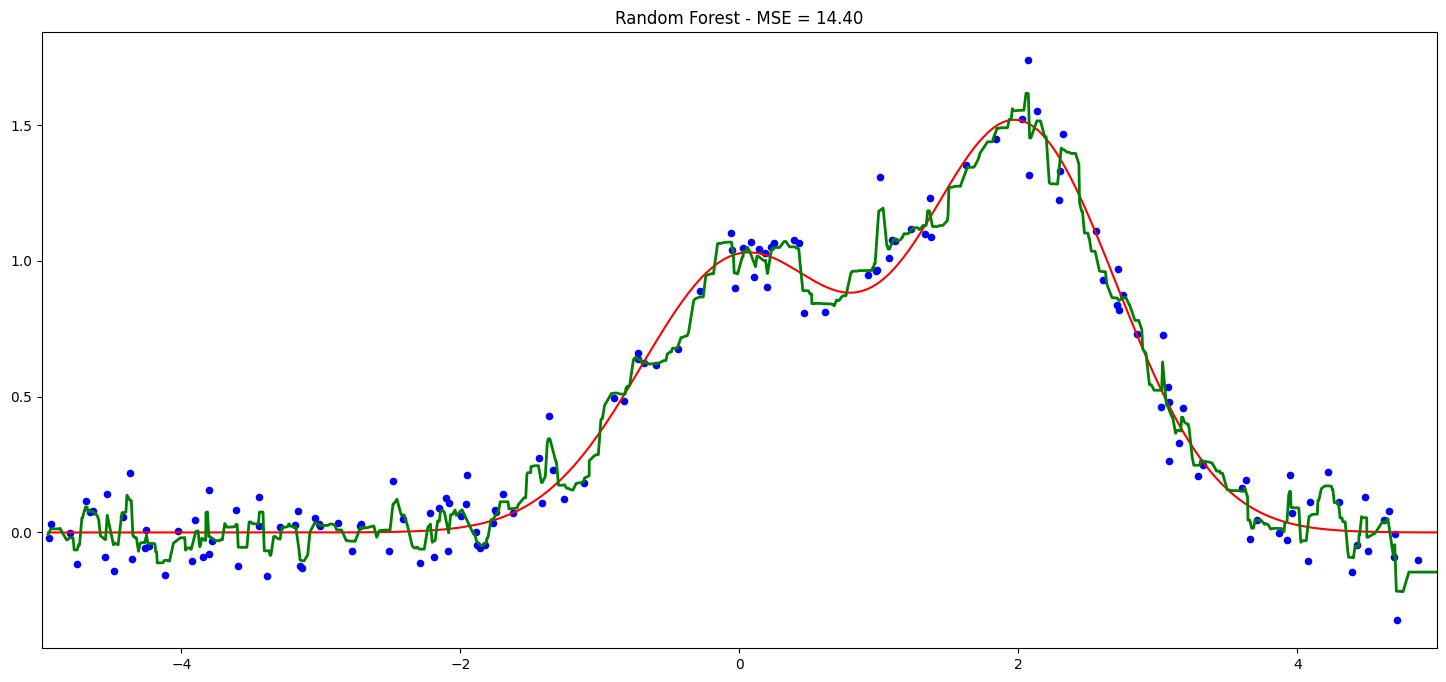

In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000)
rf_reg.fit(X_train , y_train)
rf_pred = rf_reg.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), 'r')
plt.scatter(X_train, y_train, c='b', s=20)
plt.plot(X_test, rf_pred, 'g', lw=2)
plt.xlim([-5,5])
plt.title("Random Forest - MSE = %.2f" %np.sum((y_test - rf_pred)**2))
plt.show()